In [1]:
# all imports
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from pycaret.classification import ClassificationExperiment
from flaml import AutoML
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report



In [2]:
# Load fresh data
df = pd.read_csv("data/telecom_users.csv")
df = df.drop(columns=["Unnamed: 0"])

# Convert charges to numbers
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="raise")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Previously checked assumption for new customers
mask = df["TotalCharges"].isna() & df["tenure"].eq(0)
df.loc[mask, "TotalCharges"] = 0

# Separate features and target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

# Preserve our original split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Remaining missing values:", X_train.isna().sum().sum())

Training shape: (4788, 19)
Remaining missing values: 0


In [3]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    column for column in X_train.columns
    if column not in numeric_features
]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"),
     categorical_features)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# feature Engineering

In [4]:
# create three features with clear meanings based on cluster profiles
def engineer_features(X):
    X_new = X.copy()
    # InternetAddonCount: number of internet add-ons; zero includes customers without internet.
    addon_columns = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    X_new["InternetAddonCount"] = (
        X_new[addon_columns].eq("Yes").sum(axis=1)
    )
    # AutomaticPayment: 1 means automatic bank transfer or credit card payment.
    X_new["AutomaticPayment"] = (
        X_new["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)
    )
    # 
    # Six months is an initial cutoff to test
    X_new["NewMonthToMonth"] = (
        X_new["tenure"].le(6)
        & X_new["Contract"].eq("Month-to-month")
    ).astype(int)

    return X_new


X_train_engineered = engineer_features(X_train)

new_features = [
    "InternetAddonCount",
    "AutomaticPayment",
    "NewMonthToMonth"
]

display(X_train_engineered[new_features].head())

,InternetAddonCount,AutomaticPayment,NewMonthToMonth
3625,5,0,0
2608,3,1,0
4856,0,1,0
3303,1,0,0
1089,3,1,0


In [8]:
def engineer_household_features(X):
    X_new = engineer_features(X)

    household_labels = {
        (False, False): "Neither",
        (True, False): "Partner only",
        (False, True): "Dependents only",
        (True, True): "Partner and dependents"
    }

    X_new["HouseholdType"] = [
        household_labels[(partner == "Yes", dependents == "Yes")]
        for partner, dependents in zip(
            X_new["Partner"], X_new["Dependents"]
        )
    ]

    X_new["HouseholdMultipleLines"] = (
        (
            X_new["Partner"].eq("Yes")
            | X_new["Dependents"].eq("Yes")
        )
        & X_new["MultipleLines"].eq("Yes")
    ).astype(int)

    X_new["NoPhoneService"] = (
        X_new["PhoneService"].eq("No")
    ).astype(int)

    X_new["NoInternetService"] = (
        X_new["InternetService"].eq("No")
    ).astype(int)

    return X_new


X_train_v2 = engineer_features(X_train)
X_train_v3 = engineer_household_features(X_train)

household_features = [
    "HouseholdType",
    "HouseholdMultipleLines",
    "NoPhoneService",
    "NoInternetService"
]

display(X_train_v3[household_features].head())
print("V2 shape:", X_train_v2.shape)
print("V3 shape:", X_train_v3.shape)

,HouseholdType,HouseholdMultipleLines,NoPhoneService,NoInternetService
3625,Neither,0,0,0
2608,Neither,0,0,0
4856,Partner and dependents,0,0,1
3303,Neither,0,0,0
1089,Partner and dependents,0,0,0


V2 shape: (4788, 22)
V3 shape: (4788, 26)


In [9]:
X_train_v3 = engineer_household_features(X_train)

engineered_columns = new_features + [
    "HouseholdType",
    "HouseholdMultipleLines",
    "NoPhoneService",
    "NoInternetService"
]

feature_table = X_train_v3[engineered_columns].copy()
feature_table["Churn"] = y_train

display(feature_table.head(10))

,InternetAddonCount,AutomaticPayment,NewMonthToMonth,HouseholdType,HouseholdMultipleLines,NoPhoneService,NoInternetService,Churn
3625,5,0,0,Neither,0,0,0,0
2608,3,1,0,Neither,0,0,0,0
4856,0,1,0,Partner and dependents,0,0,1,0
3303,1,0,0,Neither,0,0,0,0
1089,3,1,0,Partner and dependents,0,0,0,1
928,0,0,1,Neither,0,0,0,1
5010,2,1,0,Partner only,0,0,0,0
774,2,1,0,Partner only,0,0,0,1
4201,0,0,1,Neither,0,0,1,0
143,1,0,1,Neither,0,0,0,1


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

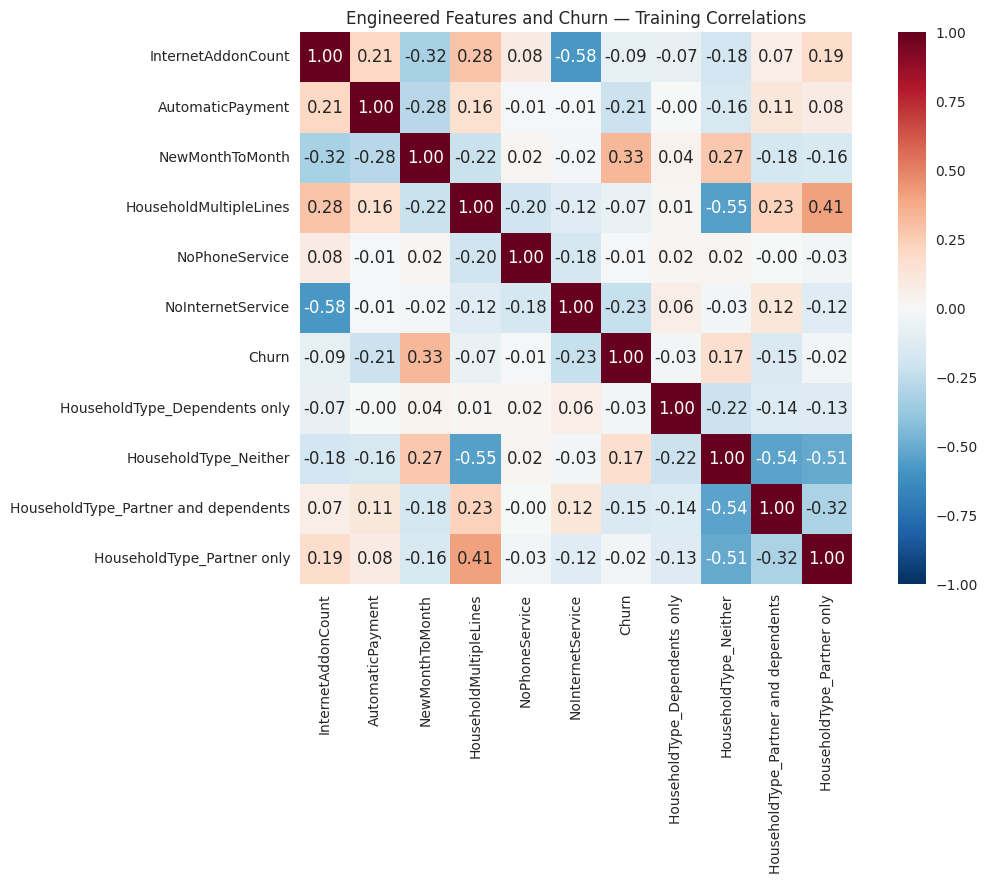

In [10]:
# correlation heatmap, encode HouseholdType because it contains text:
correlation_data = pd.get_dummies(
    feature_table,
    columns=["HouseholdType"],
    dtype=int
)

correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax
)

ax.set_title("Engineered Features and Churn — Training Correlations")
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# compare V2, V2 + household features, and all new features, keeping balanced LR, the same folds, and threshold 0.57.
experiments = {
    "V2": X_train_v2,
    "V2 + household": X_train_v3.drop(
        columns=["NoPhoneService", "NoInternetService"]
    ),
    "V3 all": X_train_v3
}

comparison_rows = []
household_oof = {}

for name, features in experiments.items():
    numeric_columns = numeric_features + new_features + [
        column for column in [
            "HouseholdMultipleLines",
            "NoPhoneService",
            "NoInternetService"
        ]
        if column in features.columns
    ]

    categorical_columns = categorical_features + [
        column for column in ["HouseholdType"]
        if column in features.columns
    ]

    model = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("numeric", StandardScaler(), numeric_columns),
            ("categorical", OneHotEncoder(handle_unknown="ignore"),
             categorical_columns)
        ])),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    probabilities = cross_val_predict(
        model,
        features,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    household_oof[name] = probabilities
    predictions = (probabilities >= 0.57).astype(int)

    comparison_rows.append({
        "Features": name,
        "Precision": precision_score(
            y_train, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_train, predictions, zero_division=0
        ),
        "F1": f1_score(y_train, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_train, probabilities)
    })

household_comparison = pd.DataFrame(
    comparison_rows
).set_index("Features")

display(household_comparison.round(4))

,Precision,Recall,F1,ROC AUC
Features,,,,
V2,0.5589,0.7400,0.6368,0.8473
V2 + household,0.5581,0.7384,0.6357,0.8471
V3 all,0.5585,0.7376,0.6357,0.8471


***
The new features didn’t improve this model.

V2 F1: 0.6368
V2 + household F1: 0.6357
V3 all F1: 0.6357

Precision, recall, and ROC AUC also stayed almost unchanged. Keep V2 as the selected feature set.

The household combinations added little beyond the original columns. NoPhoneService and NoInternetService repeat information already encoded.
***

### Result

- Household features and explicit no-service indicators did not improve
  balanced logistic regression under the same five folds and threshold 0.57.
- V2 achieved F1 0.6368; both extended versions achieved 0.6357.
- Retain the V2 feature set for the selected model.
- Correlation with churn alone does not guarantee additional predictive value.

#### replacing original columns with their grouped versions, instead of keeping both. For 
Example:

Replace Partner and Dependents with HouseholdType.
Replace PaymentMethod with AutomaticPayment.

In [12]:
# We’ll test each replacement separately, then both together, keeping the same folds and threshold 0.57.
# V2 features plus HouseholdType, without the other V3 additions
household_base = X_train_v2.copy()
household_base["HouseholdType"] = X_train_v3["HouseholdType"]

replacement_experiments = {
    "V2 reference": X_train_v2,
    "Replace Partner + Dependents": household_base.drop(
        columns=["Partner", "Dependents"]
    ),
    "Replace PaymentMethod": X_train_v2.drop(
        columns=["PaymentMethod"]
    ),
    "Both replacements": household_base.drop(
        columns=["Partner", "Dependents", "PaymentMethod"]
    )
}

replacement_rows = []

for name, features in replacement_experiments.items():
    numeric_columns = numeric_features + new_features

    categorical_columns = [
        column for column in features.columns
        if column not in numeric_columns
    ]

    candidate = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("numeric", StandardScaler(), numeric_columns),
            ("categorical", OneHotEncoder(handle_unknown="ignore"),
             categorical_columns)
        ])),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    probabilities = cross_val_predict(
        candidate,
        features,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    predictions = (probabilities >= 0.57).astype(int)

    replacement_rows.append({
        "Experiment": name,
        "Input columns": features.shape[1],
        "Precision": precision_score(
            y_train, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_train, predictions, zero_division=0
        ),
        "F1": f1_score(y_train, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_train, probabilities)
    })

replacement_results = pd.DataFrame(
    replacement_rows
).set_index("Experiment")

display(replacement_results.round(4))

,Input columns,Precision,Recall,F1,ROC AUC
Experiment,,,,,
V2 reference,22,0.5589,0.7400,0.6368,0.8473
Replace Partner + Dependents,21,0.5589,0.7400,0.6368,0.8472
Replace PaymentMethod,21,0.5555,0.7415,0.6352,0.8471
Both replacements,20,0.5531,0.7392,0.6327,0.8470


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

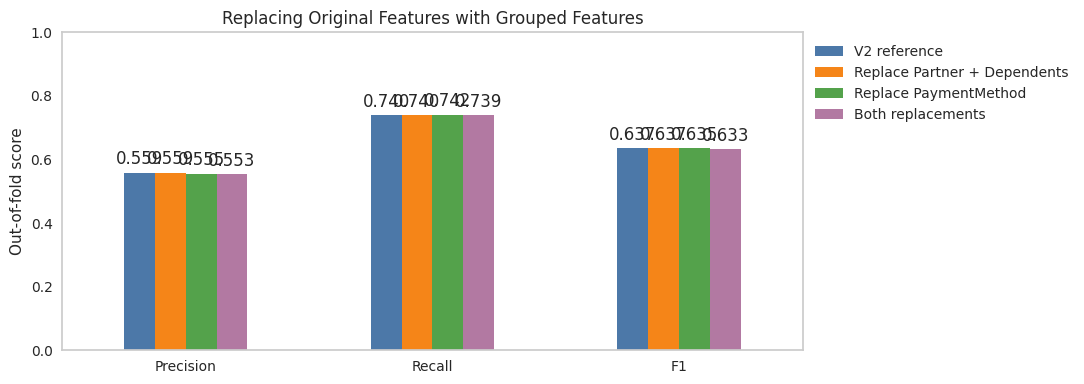

In [13]:
# plot
ax = replacement_results[["Precision", "Recall", "F1"]].T.plot.bar(
    figsize=(11, 4),
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"],
    rot=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.set_ylim(0, 1)
ax.set_ylabel("Out-of-fold score")
ax.set_xlabel("")
ax.set_title("Replacing Original Features with Grouped Features")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(False)

plt.tight_layout()
plt.show()

Grouped Feature Replacement Results

- Replacing Partner and Dependents with HouseholdType preserved F1 (0.6368).
- Replacing PaymentMethod with AutomaticPayment slightly reduced F1.
- Combining both replacements reduced F1 to 0.6327.
- Retain V2; grouping did not improve predictive performance in this experiment.

In [14]:
# test replacing the original columns that feed InternetAddonCount and AutomaticPayment.

#For NewMonthToMonth, keep tenure and Contract: a single binary flag loses most of their information.
addon_columns = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

v2_replacement_experiments = {
    "V2 reference": X_train_v2,
    "Replace six add-ons with count": X_train_v2.drop(
        columns=addon_columns
    ),
    "Replace payment with automatic flag": X_train_v2.drop(
        columns=["PaymentMethod"]
    ),
    "Replace add-ons and payment": X_train_v2.drop(
        columns=addon_columns + ["PaymentMethod"]
    )
}

v2_replacement_rows = []

for name, features in v2_replacement_experiments.items():
    numeric_columns = numeric_features + new_features

    categorical_columns = [
        column for column in features.columns
        if column not in numeric_columns
    ]

    candidate = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("numeric", StandardScaler(), numeric_columns),
            ("categorical", OneHotEncoder(handle_unknown="ignore"),
             categorical_columns)
        ])),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    probabilities = cross_val_predict(
        candidate,
        features,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    predictions = (probabilities >= 0.57).astype(int)

    v2_replacement_rows.append({
        "Experiment": name,
        "Input columns": features.shape[1],
        "Precision": precision_score(
            y_train, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_train, predictions, zero_division=0
        ),
        "F1": f1_score(y_train, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_train, probabilities)
    })

v2_replacement_results = pd.DataFrame(
    v2_replacement_rows
).set_index("Experiment")

display(v2_replacement_results.round(4))


,Input columns,Precision,Recall,F1,ROC AUC
Experiment,,,,,
V2 reference,22,0.5589,0.7400,0.6368,0.8473
Replace six add-ons with count,16,0.5521,0.7478,0.6352,0.8465
Replace payment with automatic flag,21,0.5555,0.7415,0.6352,0.8471
Replace add-ons and payment,15,0.5484,0.7368,0.6288,0.8462


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

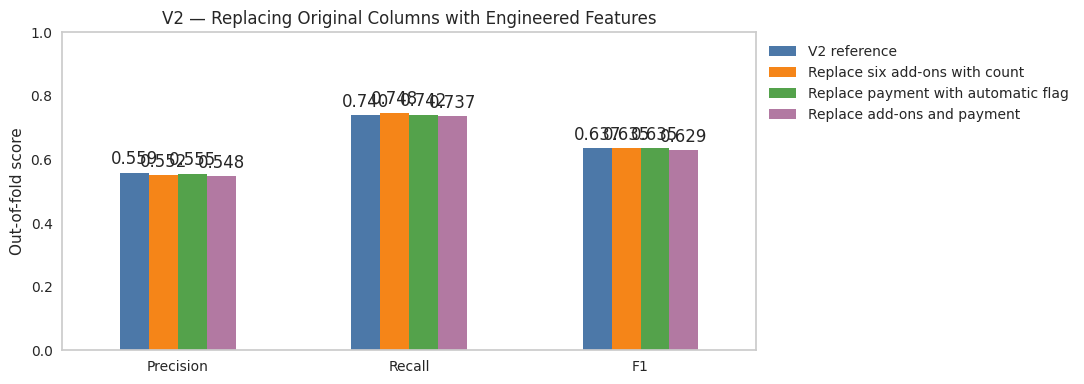

In [15]:
ax = v2_replacement_results[["Precision", "Recall", "F1"]].T.plot.bar(
    figsize=(11, 4),
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"],
    rot=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.set_ylim(0, 1)
ax.set_ylabel("Out-of-fold score")
ax.set_xlabel("")
ax.set_title("V2 — Replacing Original Columns with Engineered Features")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(False)

plt.tight_layout()
plt.show()

V2 still has the highest F1: 0.6368.

Replace six add-ons with count: F1 0.6352, almost unchanged. Recall increases slightly, but precision decreases. This is a reasonable simpler candidate.
Replace payment with automatic flag: F1 0.6352, also slightly lower.
Replace both: F1 0.6288, the largest decrease.